<a href="https://colab.research.google.com/github/rawinnoorh-gif/capston-Project-2/blob/main/Prophet_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Prophet Model — Daily Inbound Forecasting per DC
# Mirrors the CatBoost notebook for apples-to-apples comparison
#
# Shared settings (identical to CatBoost):
#   - Target        : Daily Inbound
#   - Grouping      : per DC (75 separate models)
#   - Train/Test    : last 30 days per DC = test
#   - Metrics       : MAE + MAPE (safe, uses max(1, abs(y)))
#   - Forecast      : 14 days ahead
#   - Output cols   : Date, Province, Region, City, DCs, pred_daily_inbound
#
# Prophet-specific:
#   - No lag/rolling features needed (Prophet builds its own)
#   - Custom Saudi weekly seasonality (Fri+Sat weekend)
#   - Multiplicative mode for high-variance DCs
#   - Predictions clipped to 0 (no negatives)
# ============================================================


# ============================================================
# 1. Install & Import
# ============================================================

# Run this in terminal / Colab first:
# !pip install prophet openpyxl

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# ============================================================
# 2. Load Data  (same file as CatBoost notebook)
# ============================================================

# --- Google Colab: uncomment below ---
from google.colab import files
uploaded = files.upload()
FILE_PATH = 'LM DCs Data.xlsx'

# --- Local / other env: set path directly ---
# FILE_PATH = 'LM DCs Data.xlsx'

df = pd.read_excel(FILE_PATH, sheet_name='Volume Data')
print(df.head())

Saving LM DCs Data.xlsx to LM DCs Data.xlsx
  Province       Region City                 DCs       Date  Year  Month  Day  \
0     West  مكة المكرمة  جدة  نقطة توزيع أبحر 16 2025-01-01  2025      1    1   
1     West  مكة المكرمة  جدة  نقطة توزيع أبحر 16 2025-01-02  2025      1    2   
2     West  مكة المكرمة  جدة  نقطة توزيع أبحر 16 2025-01-03  2025      1    3   
3     West  مكة المكرمة  جدة  نقطة توزيع أبحر 16 2025-01-04  2025      1    4   
4     West  مكة المكرمة  جدة  نقطة توزيع أبحر 16 2025-01-05  2025      1    5   

   Day Name  Week Number Year - Month  Daily Inbound  
0  الأربعاء            1      2025-01            498  
1    الخميس            1      2025-01            495  
2    الجمعة            1      2025-01             31  
3     السبت            1      2025-01            448  
4     الأحد            2      2025-01            131  


In [ ]:
# ============================================================
# 3. Config  — identical constants to CatBoost notebook
# ============================================================

TARGET    = 'Daily Inbound'
DATE_COL  = 'Date'
GROUP_COL = 'DCs'
TEST_DAYS = 30          # last 30 days per DC → test set  (same as CatBoost)
FCST_DAYS = 14          # forecast horizon                (same as CatBoost)


In [ ]:
# ============================================================
# 4. Pre-process
# ============================================================

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.dropna(subset=[TARGET]).copy()
df = df.sort_values([GROUP_COL, DATE_COL]).reset_index(drop=True)

print(f'Total rows : {len(df)}')
print(f'DCs        : {df[GROUP_COL].nunique()}')
print(f'Date range : {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}')


Total rows : 24848
DCs        : 75
Date range : 2025-01-01 → 2025-11-30


In [ ]:
# ============================================================
# 5. Train / Test split  — SAME logic as CatBoost
#    Last TEST_DAYS per DC = test; everything before = train
# ============================================================

def time_split_last_n_days_per_group(data, n_days=30):
    """
    Splits dataset so the last n_days of each DC become the test set.
    Identical to the CatBoost notebook split function.
    """
    d = data.copy()
    d['max_date_per_dc'] = d.groupby(GROUP_COL)[DATE_COL].transform('max')
    d['cutoff_date']     = d['max_date_per_dc'] - pd.Timedelta(days=n_days)
    train = d[d[DATE_COL] <= d['cutoff_date']].copy()
    test  = d[d[DATE_COL] >  d['cutoff_date']].copy()
    train = train.drop(columns=['max_date_per_dc', 'cutoff_date'])
    test  = test.drop(columns=['max_date_per_dc', 'cutoff_date'])
    return train, test


train_df, test_df = time_split_last_n_days_per_group(df, n_days=TEST_DAYS)

print('Train shape     :', train_df.shape)
print('Test  shape     :', test_df.shape)
print('Train last date :', train_df[DATE_COL].max().date())
print('Test  first date:', test_df[DATE_COL].min().date())

Train shape     : (22622, 12)
Test  shape     : (2226, 12)
Train last date : 2025-10-31
Test  first date: 2025-11-01


In [ ]:
# ============================================================
# 6. Helper — build & predict with a Prophet model for one DC
# ============================================================

def build_prophet(dc_train: pd.DataFrame) -> Prophet:
    """
    Fit a Prophet model on a single DC's training data.

    Settings rationale:
    - yearly_seasonality = True   → captures annual pattern in ~11 months of data
    - weekly_seasonality = False  → replaced by custom Saudi-week seasonality below
    - daily_seasonality  = False  → daily data, no intraday pattern needed
    - seasonality_mode   = 'multiplicative'
                                  → handles DCs with large volume variance better
                                    than additive mode
    - Custom 'weekly_saudi': period=7, fourier_order=3
                                  → aligns weekly cycle to Saudi calendar
                                    (Fri+Sat weekend vs default Sat+Sun)
    """
    ts = dc_train[[DATE_COL, TARGET]].rename(
        columns={DATE_COL: 'ds', TARGET: 'y'}
    )

    m = Prophet(
        yearly_seasonality  = True,
        weekly_seasonality  = False,   # replaced by custom Saudi seasonality
        daily_seasonality   = False,
        seasonality_mode    = 'multiplicative',
        interval_width      = 0.95,
    )

    # Custom weekly seasonality aligned to Saudi week
    m.add_seasonality(
        name         = 'weekly_saudi',
        period       = 7,
        fourier_order= 3,
    )

    m.fit(ts, iter=500)
    return m


def prophet_predict(model: Prophet, future_dates: pd.Series) -> np.ndarray:
    """Return clipped (>=0) yhat values for the given dates."""
    future   = pd.DataFrame({'ds': future_dates})
    forecast = model.predict(future)
    return np.maximum(0, forecast['yhat'].values)   # clip negatives → 0

In [ ]:
# ============================================================
# 7. Train one Prophet model per DC + Predict on test set
# ============================================================

dc_models  = {}     # store trained models keyed by DC name
test_preds = []     # collect per-DC DataFrames with predictions

dcs = df[GROUP_COL].unique()
print(f'\nFitting {len(dcs)} Prophet models...')

for i, dc in enumerate(dcs):
    dc_train = train_df[train_df[GROUP_COL] == dc].copy()
    dc_test  = test_df[test_df[GROUP_COL]   == dc].copy()

    if len(dc_train) < 10:
        print(f'  [{i+1}/{len(dcs)}] SKIP {dc} — only {len(dc_train)} train rows')
        continue

    model = build_prophet(dc_train)
    dc_models[dc] = model

    preds      = prophet_predict(model, dc_test[DATE_COL])
    dc_test    = dc_test.copy()
    dc_test['pred'] = preds
    test_preds.append(dc_test)

    if (i + 1) % 15 == 0 or (i + 1) == len(dcs):
        print(f'  [{i+1}/{len(dcs)}] done')

test_results = pd.concat(test_preds, ignore_index=True)
print(f'\nTotal test predictions: {len(test_results)}')


Fitting 75 Prophet models...
  [15/75] done
  [30/75] done
  [45/75] done
  [60/75] done
  [75/75] done

Total test predictions: 2226


In [ ]:
# ============================================================
# 8. Evaluate  — SAME formulas as CatBoost notebook
# ============================================================

y_test = test_results[TARGET]
pred   = test_results['pred']

mae  = mean_absolute_error(y_test, pred)
mape = np.mean(np.abs((y_test - pred) / np.maximum(1, np.abs(y_test)))) * 100

print(f'\nProphet Test MAE : {mae:,.2f}')
print(f'Prophet Test MAPE: {mape:,.2f}%')



Prophet Test MAE : 193.62
Prophet Test MAPE: 316.24%


In [ ]:
# ============================================================
# 9. Baseline comparison  — same baselines as CatBoost
# ============================================================

test_sorted        = test_results.sort_values([GROUP_COL, DATE_COL]).copy()
test_sorted['lag_1'] = test_sorted.groupby(GROUP_COL)[TARGET].shift(1)
test_sorted        = test_sorted.dropna(subset=['lag_1'])

mae_lag1  = mean_absolute_error(test_sorted[TARGET], test_sorted['lag_1'])
mape_lag1 = np.mean(np.abs(
    (test_sorted[TARGET] - test_sorted['lag_1']) /
    np.maximum(1, np.abs(test_sorted[TARGET]))
)) * 100

test_sorted['lag_7'] = test_sorted.groupby(GROUP_COL)[TARGET].shift(7)
test_lag7  = test_sorted.dropna(subset=['lag_7'])

mae_lag7  = mean_absolute_error(test_lag7[TARGET], test_lag7['lag_7'])
mape_lag7 = np.mean(np.abs(
    (test_lag7[TARGET] - test_lag7['lag_7']) /
    np.maximum(1, np.abs(test_lag7[TARGET]))
)) * 100

results = pd.DataFrame({
    'Model'    : ['Lag_1', 'Lag_7', 'Prophet'],
    'MAE'      : [mae_lag1, mae_lag7, mae],
    'MAPE (%)' : [mape_lag1, mape_lag7, mape],
})
print('\n--- Baseline Comparison ---')
print(results.sort_values('MAE').to_string(index=False))


--- Baseline Comparison ---
  Model        MAE    MAPE (%)
Prophet 193.624528  316.238837
  Lag_7 241.012300  270.325433
  Lag_1 260.802417 1554.049071


In [ ]:
# ============================================================
# 10. Per-DC MAE  — same structure as CatBoost
# ============================================================

test_results['abs_error'] = (test_results[TARGET] - test_results['pred']).abs()

dc_mae = test_results.groupby(GROUP_COL)['abs_error'].mean().sort_values(ascending=False)

print('\nWorst 10 DCs by MAE:')
print(dc_mae.head(10))

print('\nPer-DC MAE summary:')
print(dc_mae.describe())



Worst 10 DCs by MAE:
DCs
نقطة توزيع الرياض 2              2147.479749
نقطة توزيع جدة 25                1082.997413
نقطة توزيع الدمام  14            1041.385134
نقطة توزيع مكة المكرمة 20         983.806402
نقطة توزيع الرياض 1               862.483739
نقطة توزيع الطائف 5               690.227066
نقطة توزيع الأحساء 13             569.646338
نقطة توزيع المدينة المنورة 24     546.273650
نقطة توزيع جازان 8                396.252920
نقطة توزيع حائل المجمع            369.445841
Name: abs_error, dtype: float64

Per-DC MAE summary:
count      75.000000
mean      191.937340
std       330.906458
min         9.933556
25%        35.891726
50%        70.889299
75%       181.423401
max      2147.479749
Name: abs_error, dtype: float64


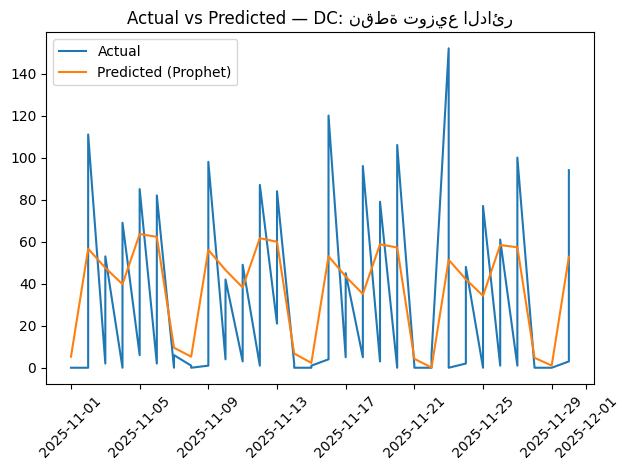

In [ ]:
# ============================================================
# 11. Actual vs Predicted plot  — same DC as CatBoost default
# ============================================================

dc_example = test_results[GROUP_COL].value_counts().index[0]
one        = test_results[test_results[GROUP_COL] == dc_example].sort_values(DATE_COL)

plt.figure()
plt.plot(one[DATE_COL], one[TARGET],  label='Actual')
plt.plot(one[DATE_COL], one['pred'],  label='Predicted (Prophet)')
plt.title(f'Actual vs Predicted — DC: {dc_example}')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 12. Forecast next 14 days  — same horizon as CatBoost
# ============================================================

forecasts = []

for dc in dc_models:
    dc_all       = df[df[GROUP_COL] == dc]
    last_date    = dc_all[DATE_COL].max()
    future_dates = pd.date_range(
        start   = last_date + pd.Timedelta(days=1),
        periods = FCST_DAYS,
        freq    = 'D'
    )

    preds = prophet_predict(dc_models[dc], future_dates)

    meta = dc_all.iloc[-1][['Province', 'Region', 'City', GROUP_COL]].to_dict()

    tmp = pd.DataFrame({
        DATE_COL             : future_dates,
        'Province'           : meta['Province'],
        'Region'             : meta['Region'],
        'City'               : meta['City'],
        GROUP_COL            : dc,
        'pred_daily_inbound' : preds,
    })
    forecasts.append(tmp)

future_14 = pd.concat(forecasts, ignore_index=True)

print('\nForecast summary:')
print('  Rows     :', len(future_14))
print('  Date range:', future_14[DATE_COL].min().date(), '→', future_14[DATE_COL].max().date())
print('  DCs      :', future_14[GROUP_COL].nunique())
print(future_14.head(20).to_string(index=False))



Forecast summary:
  Rows     : 1050
  Date range: 2025-12-01 → 2025-12-14
  DCs      : 75
      Date Province      Region    City                   DCs  pred_daily_inbound
2025-12-01     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          638.339697
2025-12-02     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          759.391564
2025-12-03     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          713.415954
2025-12-04     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          658.840822
2025-12-05     West مكة المكرمة     جدة    نقطة توزيع أبحر 16           97.103552
2025-12-06     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          607.612056
2025-12-07     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          430.280886
2025-12-08     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          592.521713
2025-12-09     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          715.018388
2025-12-10     West مكة المكرمة     جدة    نقطة توزيع أبحر 16          670.941998
2025-12

In [ ]:
# ============================================================
# 13. Export results
# ============================================================

future_14.to_excel('prophet_forecast_next_14_days.xlsx', index=False)
print('\nSaved: prophet_forecast_next_14_days.xlsx')

test_results[[DATE_COL, GROUP_COL, TARGET, 'pred', 'abs_error']].to_excel(
    'prophet_test_errors.xlsx', index=False
)
print('Saved: prophet_test_errors.xlsx')



Saved: prophet_forecast_next_14_days.xlsx
Saved: prophet_test_errors.xlsx


In [ ]:
# ============================================================
# 14. Final side-by-side comparison with CatBoost
#     Update catboost_mae / catboost_mape from your other notebook
# ============================================================

catboost_mae  = 156.59    # from CatBoost notebook
catboost_mape = 151.00    # from CatBoost notebook

comparison = pd.DataFrame({
    'Model'    : ['Lag_1', 'Lag_7', 'Prophet', 'CatBoost'],
    'MAE'      : [mae_lag1, mae_lag7, mae, catboost_mae],
    'MAPE (%)' : [mape_lag1, mape_lag7, mape, catboost_mape],
})

print('\n=== Final Model Comparison ===')
print(comparison.sort_values('MAE').to_string(index=False))



=== Final Model Comparison ===
   Model        MAE    MAPE (%)
CatBoost 156.590000  151.000000
 Prophet 193.624528  316.238837
   Lag_7 241.012300  270.325433
   Lag_1 260.802417 1554.049071
